In [2]:
!pip install supabase pandas numpy scikit-learn matplotlib seaborn python-dotenv


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from supabase import create_client
from sklearn.preprocessing import MinMaxScaler
from dotenv import load_dotenv

load_dotenv()

supabase = create_client(
    os.environ["SUPABASE_URL"],
    os.environ["SUPABASE_KEY"]
)

In [ ]:
# Supabase returns max 1000 rows per call — paginate to get all
def fetch_all(table):
    rows = []
    page = 0
    batch = 1000
    while True:
        res = supabase.table(table)\
                      .select("*")\
                      .range(page * batch, (page + 1) * batch - 1)\
                      .execute()
        if not res.data:
            break
        rows.extend(res.data)
        if len(res.data) < batch:
            break
        page += 1
    return pd.DataFrame(rows)

df = fetch_all("events")
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
df.head(3)

In [ ]:
print("=== Shape ===")
print(df.shape)

print("\n=== Dtypes ===")
print(df.dtypes)

print("\n=== Null counts ===")
null_df = pd.DataFrame({
    "nulls": df.isnull().sum(),
    "pct":   (df.isnull().sum() / len(df) * 100).round(1)
})
print(null_df[null_df["nulls"] > 0].sort_values("pct", ascending=False))

=== Shape ===
(198796, 19)

=== Dtypes ===
id                    object
client_id             object
session_id            object
event_type            object
duration             float64
logged_in               bool
event_description     object
orders                object
order_description     object
timestamp             object
nb_visits              int64
address               object
gender                object
age                  float64
pages_per_session     object
cart_abandonned         bool
device                object
sequence              object
is_bounce             object
dtype: object

=== Null counts ===
                    nulls   pct
duration           157106  79.0
order_description  106216  53.4
orders              92085  46.3
gender              85115  42.8
age                 85115  42.8
timestamp           83981  42.2
address             34570  17.4
pages_per_session   32401  16.3
device               2548   1.3
is_bounce            1115   0.6
event_type         

In [ ]:
df.columns

Index(['id', 'client_id', 'session_id', 'event_type', 'duration', 'logged_in',
       'event_description', 'orders', 'order_description', 'timestamp',
       'nb_visits', 'address', 'gender', 'age', 'pages_per_session',
       'cart_abandonned', 'device', 'sequence', 'is_bounce'],
      dtype='object')

In [ ]:
def safe_flatten(df, col, prefix):
    expanded = df[col].apply(lambda x: x if isinstance(x, dict) else {})
    flat = pd.json_normalize(expanded)
    flat.columns = [f"{prefix}_{c}" for c in flat.columns]
    return pd.concat([df.drop(columns=[col]), flat], axis=1)

In [ ]:
if df["event_description"].dtype == object:
    df = safe_flatten(df, "event_description", "ed")

if "pages_per_session" in df.columns and df["pages_per_session"].dtype == object:
    df = safe_flatten(df, "pages_per_session", "pps")
print(df.columns.tolist())

['id', 'client_id', 'session_id', 'event_type', 'duration', 'logged_in', 'orders', 'order_description', 'timestamp', 'nb_visits', 'address', 'gender', 'age', 'cart_abandonned', 'device', 'sequence', 'is_bounce', 'ed_query', 'ed_page_type', 'ed_event_name', 'ed_action_label', 'ed_funnel_stage', 'ed_action_source', 'ed_event_category', 'ed_action_location', 'ed_price', 'ed_quantity', 'ed_depth_pct', 'ed_product_id', 'ed_click_count', 'ed_product_name', 'ed_max_scroll_pct', 'pps_page_views', 'pps_page_views.page_views']


In [ ]:
df.head()

,id,client_id,session_id,event_type,duration,logged_in,orders,order_description,timestamp,nb_visits,...,ed_action_location,ed_price,ed_quantity,ed_depth_pct,ed_product_id,ed_click_count,ed_product_name,ed_max_scroll_pct,pps_page_views,pps_page_views.page_views
0,5a5e2172-38ff-4ac6-898a-5645650eecd9,anon_830468e5-beb6-4bc9-9358-041f1bcc5c87,sess_93e4f68e-902f-420c-9efc-b8297e217a37,page_view,NaN,False,None,None,2026-04-09T17:00:31,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,aeef96d0-310d-4d55-82a0-a09ad330b52c,anon_f174706c-5213-4d7d-80ed-2cfc779a5106,sess_d00ba92a-dd37-40f0-b196-797f64cd3d61,page_view,NaN,False,None,None,2026-04-09T08:13:03,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a77c45fa-cadc-4190-aade-c6557e789e39,anon_029aa052-d42d-43d4-b132-ca0827821d44,sess_13b7fb4d-bdfe-4575-a1aa-8587e400f188,page_view,NaN,False,None,None,2026-04-09T13:33:18,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28c0695a-7b07-44f7-875c-83809b73db8e,anon_f174706c-5213-4d7d-80ed-2cfc779a5106,sess_d00ba92a-dd37-40f0-b196-797f64cd3d61,scroll_depth,NaN,False,None,None,2026-04-09T08:13:05,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,eb8e2f83-dfdd-4a6b-8c02-b431a0e10c8c,anon_830468e5-beb6-4bc9-9358-041f1bcc5c87,sess_93e4f68e-902f-420c-9efc-b8297e217a37,page_engagement,NaN,False,None,None,2026-04-09T17:00:43,1,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df["hour_of_day"]  = df["timestamp"].dt.hour
df["day_of_week"]  = df["timestamp"].dt.dayofweek
df["is_weekend"]   = df["day_of_week"].isin([5, 6]).astype(int)
for col in ["duration", "nb_visits", "age", "orders", "revenue"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["ed_price", "ed_quantity", "ed_max_scroll_pct", "ed_click_count", "pps_page_views"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
for col in ["logged_in", "cart_abandoned", "is_bounce"]:
    if col in df.columns:
        df[col] = df[col].map({True: True, False: False, "true": True,
                                "false": False, 1: True, 0: False})\
                         .fillna(False).astype(bool)
print("Types OK")
df.dtypes

Types OK


C:\Users\eya-pc\AppData\Local\Temp\ipykernel_4284\3255828940.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)


id                                        object
client_id                                 object
session_id                                object
event_type                                object
duration                                 float64
logged_in                                   bool
orders                                   float64
order_description                         object
timestamp                    datetime64[ns, UTC]
nb_visits                                  int64
address                                   object
gender                                    object
age                                      float64
cart_abandonned                             bool
device                                    object
sequence                                  object
is_bounce                                   bool
ed_query                                  object
ed_page_type                              object
ed_event_name                             object
ed_action_label     

In [ ]:
df.columns

Index(['id', 'client_id', 'session_id', 'event_type', 'duration', 'logged_in',
       'orders', 'order_description', 'timestamp', 'nb_visits', 'address',
       'gender', 'age', 'cart_abandonned', 'device', 'sequence', 'is_bounce',
       'ed_query', 'ed_page_type', 'ed_event_name', 'ed_action_label',
       'ed_funnel_stage', 'ed_action_source', 'ed_event_category',
       'ed_action_location', 'ed_price', 'ed_quantity', 'ed_depth_pct',
       'ed_product_id', 'ed_click_count', 'ed_product_name',
       'ed_max_scroll_pct', 'pps_page_views', 'pps_page_views.page_views',
       'hour_of_day', 'day_of_week', 'is_weekend'],
      dtype='object')

In [ ]:
def safe_nunique(series):
    try:
        return series.nunique(dropna=False)
    except TypeError:
        return series.astype(str).nunique(dropna=False)

def safe_sample(series, n=3):
    try:
        vals = series.dropna().iloc[:n].tolist()
        # convert any unhashable containers to repr strings
        return [str(v) if isinstance(v, (dict, list)) else v for v in vals]
    except Exception:
        return series.dropna().astype(str).iloc[:n].tolist()

summary_rows = []
for col in df.columns:
    n_null   = df[col].isna().sum()
    pct_null = n_null / len(df) * 100
    n_unique = safe_nunique(df[col])
    sample   = safe_sample(df[col]) if n_null < len(df) else ["ALL NULL"]
    summary_rows.append({
        "column":   col,
        "dtype":    str(df[col].dtype),
        "nulls":    n_null,
        "null_%":   round(pct_null, 1),
        "unique":   n_unique,
        "sample":   sample,
    })

col_summary = pd.DataFrame(summary_rows).set_index("column")
pd.set_option("display.max_colwidth", 80)
col_summary


,dtype,nulls,null_%,unique,sample
column,,,,,
id,object,0,0.0,128901,"[5a5e2172-38ff-4ac6-898a-5645650eecd9, aeef96d0-310d-4d55-82a0-a09ad330b52c,..."
client_id,object,0,0.0,54349,"[anon_830468e5-beb6-4bc9-9358-041f1bcc5c87, anon_f174706c-5213-4d7d-80ed-2cf..."
session_id,object,0,0.0,64077,"[sess_93e4f68e-902f-420c-9efc-b8297e217a37, sess_d00ba92a-dd37-40f0-b196-797..."
event_type,object,56,0.0,35,"[page_view, page_view, page_view]"
duration,float64,157106,79.0,10700,"[0.0, 0.0, 0.0]"
logged_in,bool,0,0.0,2,"[False, False, False]"
orders,float64,104705,52.7,6,"[0.0, 0.0, 0.0]"
order_description,object,106216,53.4,3279,"[{}, {}, {}]"
timestamp,"datetime64[ns, UTC]",183353,92.2,6496,"[2026-04-09 17:00:31+00:00, 2026-04-09 08:13:03+00:00, 2026-04-09 13:33:18+0..."


In [ ]:
cat_cols  = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()

print("=== Categorical columns ===")
for col in cat_cols:
    try:
        vc = df[col].value_counts(dropna=False).head(10)
        n_unique = df[col].nunique()
    except TypeError:
        vc = df[col].astype(str).value_counts(dropna=False).head(10)
        n_unique = df[col].astype(str).nunique()
    print(f"\n── {col}  (unique={n_unique}, nulls={df[col].isna().sum():,})")
    print(vc.to_string())

print("\n=== Boolean columns ===")
for col in bool_cols:
    vc = df[col].value_counts(dropna=False)
    pct_true = df[col].sum() / len(df) * 100
    print(f"\n── {col}  (True: {pct_true:.1f}%)")


=== Categorical columns ===

── id  (unique=128901, nulls=0)
id
49373750-70b5-4264-9060-7ffa36c86cec    5
d1e5f511-6b01-46ed-92c7-f38149fefc70    5
e4c84011-5b2a-4e72-9c02-5b6d6ef45da6    5
ec119f33-807e-4480-8b36-1e453894fc93    5
3f1aebca-05d6-4386-98ad-6b4f8961d3a3    5
1078222a-885c-424d-9ea1-182eb07038fa    5
fd7af91a-a3e3-42f2-a7e6-55547521f180    5
51c0a4ee-a9e8-4052-ac73-7b87efe07418    5
e32c3033-3da4-428b-a157-af7fa727d073    5
aaa8853b-3958-4dbf-b51a-ff4c58e73b89    5

── client_id  (unique=54349, nulls=0)
client_id
anon_183703e7-5d67-4533-9e13-a61500ff8fa3    312
anon_df60b995-237e-4acf-91ad-38bb1da08359    265
anon_cdc79847-aa20-4b56-bc56-a5e26f156d36    246
anon_3192bbd8-1a61-401f-96bd-b4609704f410    230
anon_d5f01ce6-de2c-4e82-98d7-5f0ea83961b8    229
anon_c18a9fe5-115d-4e4f-85d0-ce2d59b20c6c    229
anon_7c2d3a1e-c075-4173-8e57-2da66141a4fa    208
anon_6ddab434-16f1-4075-a451-734982109fae    204
anon_17cf9664-38ab-49be-96b4-e6301d1be84d    203
anon_e6786a3f-7a1a-4e72-a7

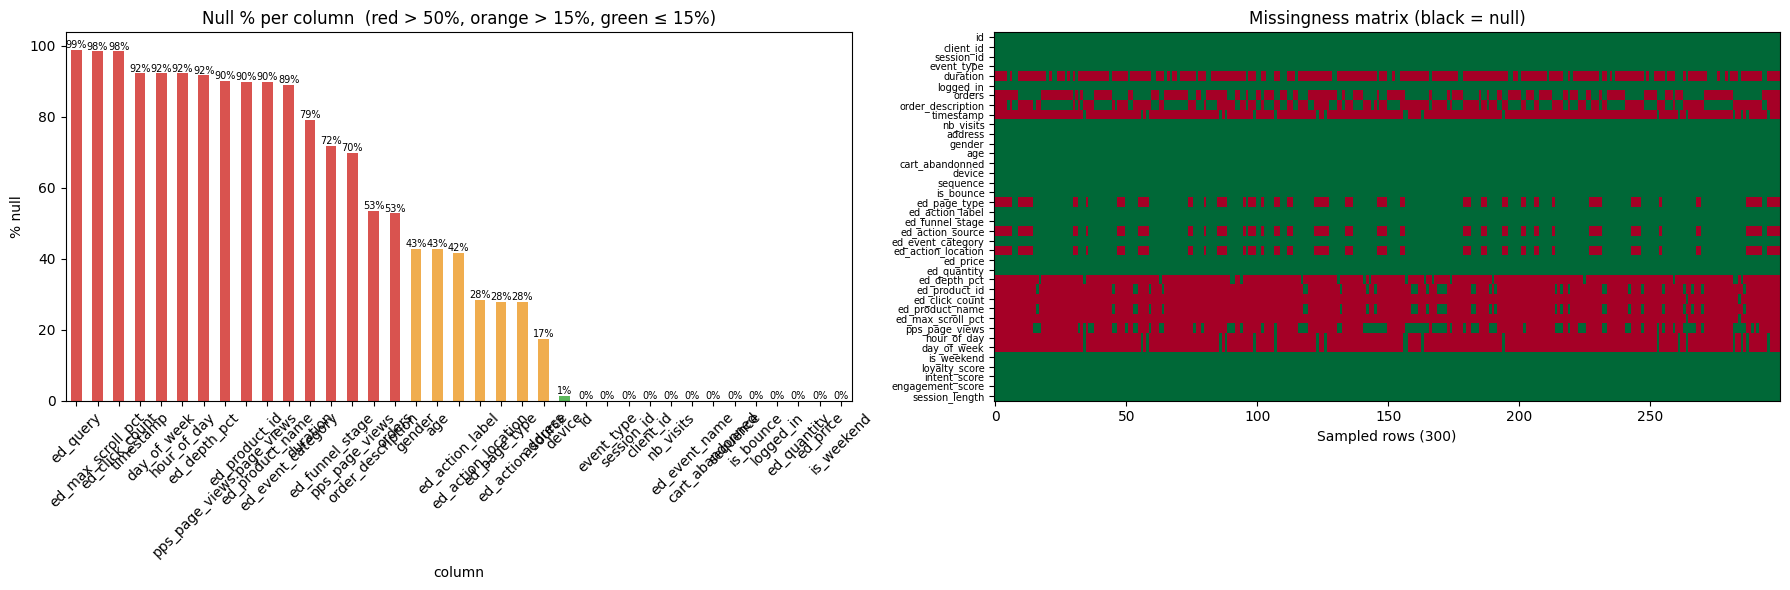

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

null_pct = col_summary["null_%"].sort_values(ascending=False)
colors = ["#d9534f" if v > 50 else "#f0ad4e" if v > 15 else "#5cb85c" for v in null_pct]
null_pct.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Null % per column  (red > 50%, orange > 15%, green ≤ 15%)")
axes[0].set_ylabel("% null")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(null_pct):
    axes[0].text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=7)
# Right: missingness matrix (sample of rows)
import random
sample_idx = sorted(random.sample(range(len(df)), min(300, len(df))))
miss_matrix = df.iloc[sample_idx].isna().astype(int)
axes[1].imshow(miss_matrix.T, aspect="auto", cmap="RdYlGn_r", interpolation="none")
axes[1].set_yticks(range(len(df.columns)))
axes[1].set_yticklabels(df.columns, fontsize=7)
axes[1].set_xlabel("Sampled rows (300)")
axes[1].set_title("Missingness matrix (black = null)")

plt.tight_layout()
plt.savefig("null_overview.png", dpi=150)
plt.show()


=== Numeric describe ===


,count,mean,std,min,25%,50%,75%,max
duration,41690.0,6977.84,35485.00,0.0,22.00,350.0,6289.5,2249041.00
orders,94091.0,0.02,0.13,0.0,0.00,0.0,0.0,4.00
nb_visits,198796.0,2.34,4.40,1.0,1.00,1.0,2.0,153.00
age,113681.0,33.21,20.51,0.0,22.00,35.0,48.0,72.00
ed_price,198796.0,11.97,53.18,0.0,0.00,0.0,0.0,774.89
ed_quantity,198796.0,1.02,0.18,1.0,1.00,1.0,1.0,3.00
ed_depth_pct,16774.0,58.99,22.29,10.0,43.00,60.0,76.0,100.00
ed_click_count,3216.0,13.13,9.83,0.0,3.75,13.0,22.0,30.00
ed_max_scroll_pct,3216.0,53.86,25.89,0.0,34.00,57.0,73.0,100.00
pps_page_views,60034.0,11.90,8.37,1.0,5.00,10.0,17.0,46.00


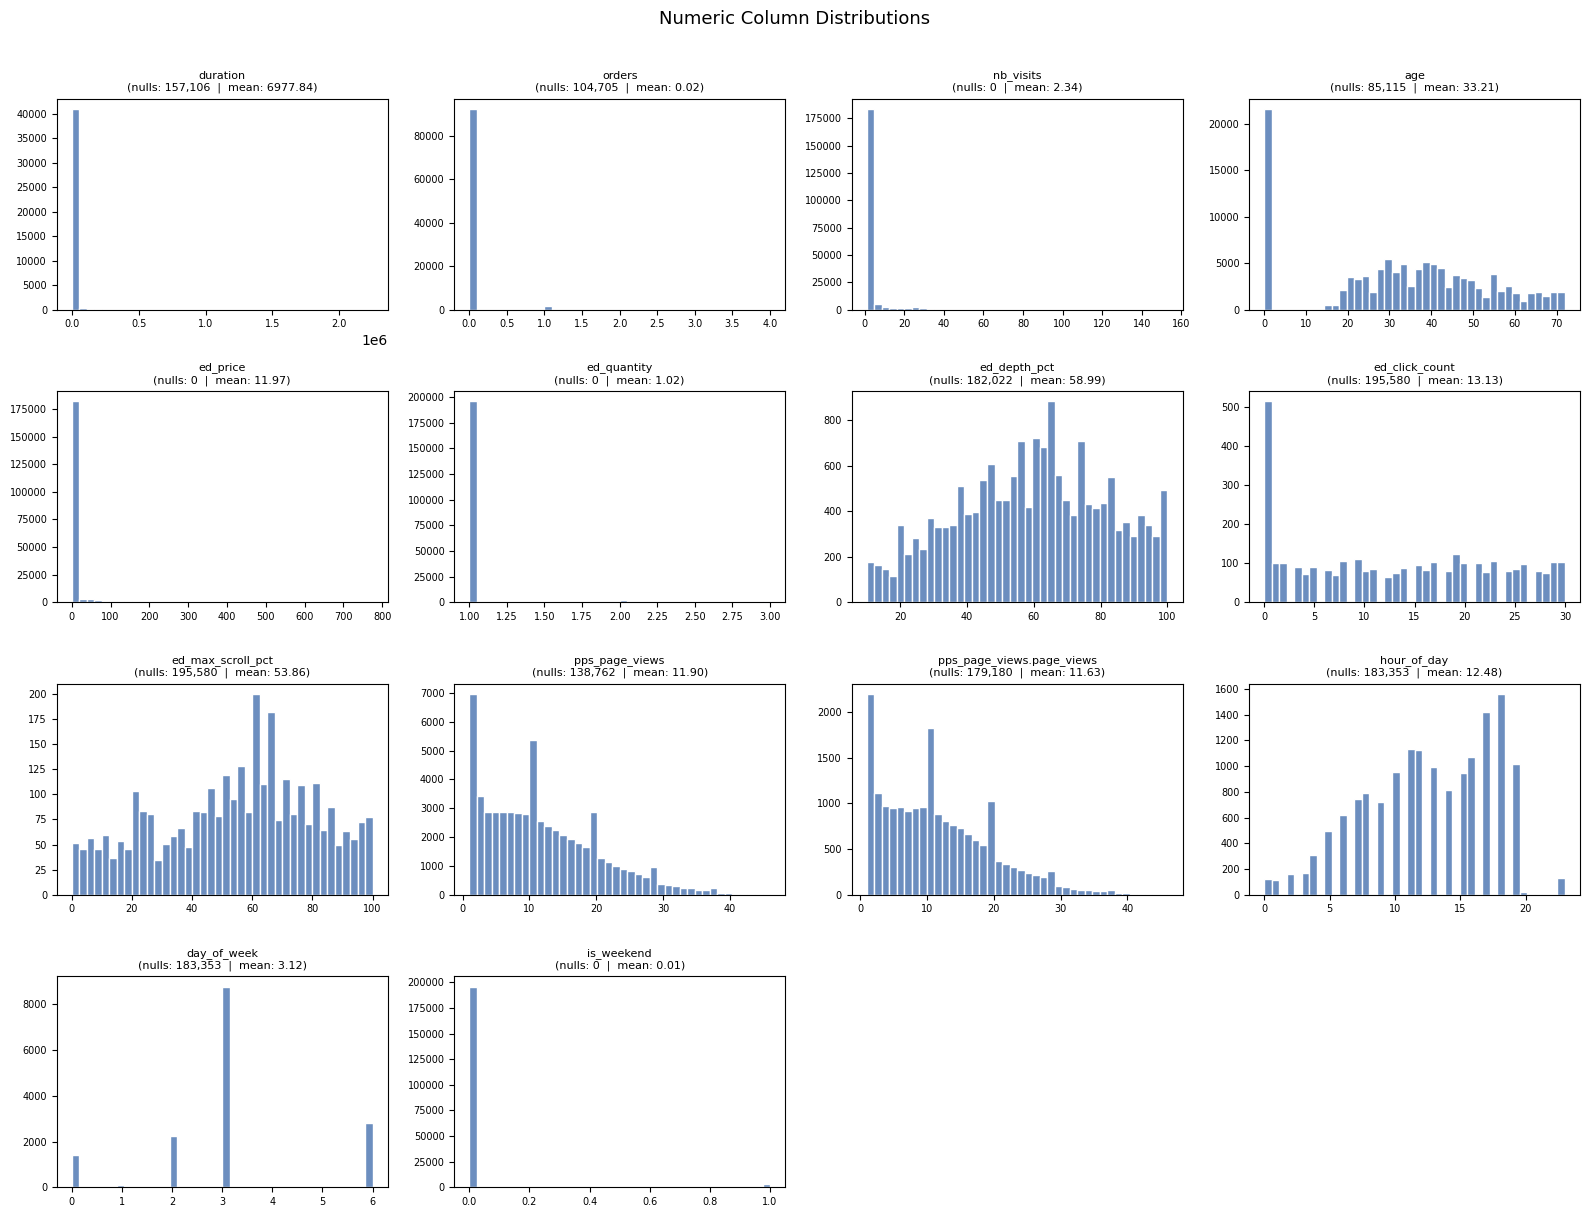

In [ ]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print("=== Numeric describe ===")
display(df[num_cols].describe().T.round(2))

n = len(num_cols)
cols_per_row = 4
rows_needed  = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(16, rows_needed * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color="#6C8EBF", edgecolor="white")
    axes[i].set_title(f"{col}\n(nulls: {df[col].isna().sum():,}  |  mean: {data.mean():.2f})", fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Column Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# pps_page_views.page_views is a duplicate of pps_page_views — drop it
df = df.drop(columns=["pps_page_views.page_views"], errors="ignore")

# ed_event_name is identical to event_type — drop it
df = df.drop(columns=["ed_event_name"], errors="ignore")

# ed_query is 98.8% null and mostly obfuscated — not useful
df = df.drop(columns=["ed_query"], errors="ignore")

# ed_product_id and ed_product_name are 89.8% null — keep but don't impute
# ed_event_category is 88.9% null — keep for context agent later

print("Columns after drop:", df.shape[1])

Columns after drop: 34


In [ ]:
df["session_id"] = df["session_id"].fillna(
    "sess_" + df["client_id"].astype(str) + "_" + df.index.astype(str)
)
# ── gender: standardize all noise to NaN ─────────────────────
df["gender"] = df.groupby("client_id")["gender"].transform(
    lambda x: x.mode()[0] if not x.mode().empty else pd.NA
)
df["gender"] = df["gender"].fillna("unknown")
df["age"] = df["age"].replace(0, pd.NA)
df["age"] = df.groupby("address")["age"].transform(
    lambda x: x.fillna(x.median())
)
df["age"] = df["age"].fillna(df["age"].median())

df["device"] = df["device"].str.split("|").str[0].str.strip().str.lower()
df["device"] = df["device"].replace({"unknown": pd.NA, "": pd.NA})
df["device"] = df["device"].where(df["device"].isin(["mobile", "desktop", "tablet"]), "other")
df["device"] = df["device"].fillna(
    df.groupby("client_id")["device"].transform(
        lambda x: x.mode()[0] if not x.mode().empty else "mobile"
    )
)
df["address"] = df.groupby("client_id")["address"].transform(
    lambda x: x.mode()[0] if not x.mode().empty else "unknown"
)
df["ed_event_category"] = df.groupby("client_id")["ed_event_category"].transform(
    lambda x: x.mode()[0] if not x.mode().empty else "unknown"
)
df["ed_action_label"] = df["ed_action_label"].fillna("none")
df["ed_funnel_stage"] = df.groupby("client_id")["ed_funnel_stage"].transform(
    lambda x: x.ffill().bfill()
)
df["ed_funnel_stage"] = df["ed_funnel_stage"].fillna("awareness")
df["ed_event_category"] = df["ed_event_category"].replace("NaN", pd.NA)

print("Dirty values cleaned ✓")
print(df["gender"].value_counts(dropna=False))
print(df["device"].value_counts(dropna=False))

c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\num

Dirty values cleaned ✓
gender
unknown    104505
F           45597
M           41462
other        7232
Name: count, dtype: int64
device
mobile     96518
desktop    78521
tablet     20948
other       2809
Name: count, dtype: int64


In [ ]:
df["loyalty_score"] = df.groupby("client_id")["event_type"].transform("count")
df["intent_score"] = df["event_type"].isin(
    ["product_view", "add_to_cart"]
).astype(int)
df["engagement_score"] = (
    (df["event_type"] == "user_engagement").astype(int) +
    (df["event_type"] == "scroll_depth").astype(int)
)
df["session_length"] = df.groupby("session_id")["event_type"].transform("count")

In [ ]:
df = df.sort_values(["client_id", "timestamp"])

df["timestamp"] = df.groupby("client_id")["timestamp"].ffill()

In [ ]:
df.drop(columns=["timestamp_filled"],inplace=True)

In [ ]:
df['timestamp'].value_counts()

timestamp
2026-04-30 15:08:07+00:00    296
2026-04-26 11:40:41+00:00    238
2026-04-09 15:02:16+00:00    229
2026-04-30 07:50:39+00:00    226
2026-04-26 18:46:37+00:00    221
                            ... 
2026-04-09 10:50:27+00:00      1
2026-04-09 10:50:25+00:00      1
2026-04-15 10:14:54+00:00      1
2026-04-15 10:14:56+00:00      1
2026-03-22 09:52:36+00:00      1
Name: count, Length: 6495, dtype: int64

In [ ]:
def parse_sequence(seq):
    if isinstance(seq, (list, np.ndarray)):
        return list(seq) if len(seq) > 0 else []    
    try:
        if pd.isna(seq) or seq == "" or seq == "['']":
            return []
    except:
        return []
    
    if isinstance(seq, str):
        seq = seq.strip().strip("[]\"'")
        if "→" in seq:
            return [s.strip() for s in seq.split("→")]
        if "->" in seq:
            return [s.strip() for s in seq.split("->")]
        return [seq]
    
    return []

df["sequence_parsed"] = df["sequence"].apply(parse_sequence)
df["sequence_len"]    = df["sequence_parsed"].apply(len)
df["last_step"]       = df["sequence_parsed"].apply(
    lambda x: x[-1] if x else "unknown"
)
print(df["sequence_parsed"].head(5))
print(df["last_step"].value_counts().head(10))

16993     [session_start, first_visit, page_view, user_engagement, page_view, user_eng...
132641    [session_start, first_visit, page_view, user_engagement, page_view, user_eng...
171164    [session_start, first_visit, page_view, user_engagement, page_view, user_eng...
181879                                [session_start, page_view, scroll, user_engagement]
181880    [session_start, page_view, scroll, user_engagement, view_promotion, page_vie...
Name: sequence_parsed, dtype: object
last_step
user_engagement     43204
page_view           38504
scroll_depth        33498
product_view        26248
add_to_cart         10187
scroll               9685
session_start        5655
search_performed     4325
page_engagement      3665
                     2809
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

ed_max_scroll_pct     195580
ed_click_count        195580
ed_depth_pct          182022
ed_product_id         178537
ed_product_name       178537
duration              157106
pps_page_views        138762
order_description     106216
orders                104705
timestamp              85291
ed_action_location     56163
ed_page_type           55048
ed_action_source       55048
event_type                56
sequence                   2
dtype: int64


In [ ]:
df.shape

(198796, 41)

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

In [ ]:
df = df.sort_values(["session_id", "timestamp"])

df["timestamp"] = df.groupby("session_id")["timestamp"].ffill()
df["timestamp"] = df.groupby("session_id")["timestamp"].bfill()

In [ ]:
df["timestamp"] = df.groupby("client_id")["timestamp"].transform(
    lambda x: x.ffill().bfill()
)

In [ ]:
df["timestamp"] = df["timestamp"].fillna(df["timestamp"].median())

In [ ]:
df["event_type"].value_counts()

event_type
page_view              43725
scroll_depth           33500
product_view           25745
session_start          16141
user_engagement        14793
first_visit            10575
add_to_cart            10366
page_engagement         8029
view_promotion          7215
scroll                  6208
search_performed        4325
view_item               3785
remove_from_cart        2523
checkout_started        2363
unknown                 2247
promo_viewed            1662
purchase_completed      1611
cart_abandon            1044
product_viewed           660
                         506
checkout_abandon         343
view_search_results      302
select_item              278
select_promotion         237
session_ended            224
begin_checkout           152
add_shipping_info         47
cart_abandoned            38
purchase                  31
click                     21
add_payment_info          18
checkout_abandoned        14
view_item_list             6
review_submitted           6
Nam

In [ ]:
df['event_type'].isnull().value_counts()

event_type
False    198740
True         56
Name: count, dtype: int64

In [ ]:
df = df[df["event_type"].notna()]

In [ ]:
df.shape

(198740, 41)

In [ ]:
df["client_id"].notna().value_counts()

client_id
True    198740
Name: count, dtype: int64

In [ ]:
df = df.sort_values(["client_id", "session_id"])

df["timestamp"] = df.groupby("session_id")["timestamp"].transform(
    lambda x: x.ffill().bfill()
)

In [ ]:
df['timestamp'].isnull().value_counts()

timestamp
False    198740
Name: count, dtype: int64

In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Series([], dtype: int64)


In [ ]:
df["ed_max_scroll_pct"] = df["ed_max_scroll_pct"].fillna(0)
df["ed_click_count"] = df["ed_click_count"].fillna(0)
df["ed_depth_pct"] = df["ed_depth_pct"].fillna(0)
df["duration"] = df["duration"].fillna(0)

In [ ]:
df["ed_product_id"] = df["ed_product_id"].fillna("none")
df["ed_product_name"] = df["ed_product_name"].fillna("none")
df["orders"] = df["orders"].fillna(0)
df["pps_page_views"] = df["pps_page_views"].fillna(0)

In [ ]:
df["has_order"] = df["orders"].notna().astype(int)

In [ ]:
df["order_description"] = df["order_description"].fillna("{}")

In [ ]:
for col in ["ed_action_location", "ed_page_type", "ed_action_source"]:
    
    mode_map = df.groupby("client_id")[col].agg(
        lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty else "unknown"
    )

    df[col] = df["client_id"].map(mode_map)

In [ ]:
df["sequence"] = df["sequence"].fillna("[]")

In [ ]:
df.columns

Index(['id', 'client_id', 'session_id', 'event_type', 'duration', 'logged_in',
       'orders', 'order_description', 'timestamp', 'nb_visits', 'address',
       'gender', 'age', 'cart_abandonned', 'device', 'sequence', 'is_bounce',
       'ed_page_type', 'ed_action_label', 'ed_funnel_stage',
       'ed_action_source', 'ed_event_category', 'ed_action_location',
       'ed_price', 'ed_quantity', 'ed_depth_pct', 'ed_product_id',
       'ed_click_count', 'ed_product_name', 'ed_max_scroll_pct',
       'pps_page_views', 'hour_of_day', 'day_of_week', 'is_weekend',
       'loyalty_score', 'intent_score', 'engagement_score', 'session_length',
       'sequence_parsed', 'sequence_len', 'last_step', 'has_order',
       'funnel_depth', 'is_purchaser', 'reached_checkout', 'deep_scroll',
       'high_engagement', 'recency_days_event'],
      dtype='object')

In [ ]:
from datetime import timezone

NOW = pd.Timestamp.now(tz="UTC")

# ── Funnel depth (you already have this, just confirm) ───────
FUNNEL_MAP = {
    "home":1,"search":2,"product_view":3,"add_to_cart":4,
    "cart_view":5,"checkout":6,"checkout_abandon":5,
    "purchase":7,"bounce":0
}
df["funnel_depth"] = df["sequence_parsed"].apply(
    lambda steps: max((FUNNEL_MAP.get(s,0) for s in steps), default=0)
)

# ── Session-level signals ────────────────────────────────────
df["is_purchaser"]     = (df["orders"] > 0).astype(int)
df["reached_checkout"] = df["funnel_depth"].ge(6).astype(int)
df["deep_scroll"]      = df["ed_max_scroll_pct"].ge(70).astype(int)
df["high_engagement"]  = (
    (df["ed_click_count"] >= 5) & (df["ed_max_scroll_pct"] >= 50)
).astype(int)

# ── Time signals ─────────────────────────────────────────────
df["recency_days_event"] = (NOW - df["timestamp"]).dt.days


print("Event-level columns added ✓")
print(df[["funnel_depth","is_purchaser","deep_scroll","high_engagement"]].describe())

Event-level columns added ✓
        funnel_depth   is_purchaser    deep_scroll  high_engagement
count  198740.000000  198740.000000  198740.000000    198740.000000
mean        0.761357       0.008338       0.004800         0.008529
std         1.518674       0.090929       0.069117         0.091957
min         0.000000       0.000000       0.000000         0.000000
25%         0.000000       0.000000       0.000000         0.000000
50%         0.000000       0.000000       0.000000         0.000000
75%         0.000000       0.000000       0.000000         0.000000
max         7.000000       1.000000       1.000000         1.000000


## Save Preprocessed Data to Supabase

Run the SQL block below once in the Supabase SQL editor to create the table, then execute the two code cells to push the data.

In [ ]:
import json

TABLE = "preprocessed_events"
BATCH = 1_000

def prep_for_supabase(df):
    out = df.copy()

    # sequence_parsed → JSON string for JSONB column
    out["sequence_parsed"] = out["sequence_parsed"].apply(
        lambda x: json.dumps(x) if isinstance(x, (list, np.ndarray)) else "[]"
    )

    # datetime → ISO string
    out["timestamp"] = out["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S+00:00")

    # inf/-inf → NaN  (pd.notnull treats inf as valid, so must sanitize first)
    out = out.replace([np.inf, -np.inf], np.nan)

    # Convert to object dtype FIRST — then None stays as None, not NaN
    out = out.astype(object)

    # NaN → None  (JSON null)
    out = out.where(pd.notnull(out), None)

    return out


df_upload = prep_for_supabase(df)
records   = df_upload.to_dict(orient="records")
total     = len(records)
errors    = []

print(f"Pushing {total:,} rows to '{TABLE}' in batches of {BATCH}…")

for start in range(0, total, BATCH):
    batch = records[start : start + BATCH]
    try:
        supabase.table(TABLE).insert(batch).execute()
        print(f"  ✓  {start + len(batch):>7,} / {total:,}")
    except Exception as e:
        errors.append((start, str(e)))
        print(f"  ✗  batch starting at {start}: {e}")

if errors:
    print(f"\n{len(errors)} batch(es) failed — see errors list above.")
else:
    print(f"\nDone — {total:,} rows saved to '{TABLE}' ✓")